# Customer Churn Analysis (Telecom Dataset)
**Objective:** The main objective of this project is to identify why customers leave (churn) and suggest ways to reduce it using a telecom dataset.

In [94]:
# Import Libraries : Pandas for data manipulation, numpy for numerical operations, and matplotlib.pyplot and seaborn for data visualization.

In [121]:
import pandas as pd

In [120]:
import numpy as np

In [119]:
import matplotlib.pyplot as plt

In [118]:
import seaborn as sns

In [117]:
# Load Dataset : Load customer_churn_data.csv dataset into a pandas DataFrame called df

In [122]:
df=pd.read_csv('customer_churn_data.csv')
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [101]:
# Understand the Data : Summary of the DataFrame, including the number of entries, column names, non-null counts, data types (Dtype), and memory usage

In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [124]:
# Generate descriptive statistics for numerical columns, showing count, mean, standard deviation, min, max, and quartile values. This helps understand the distribution and spread of numerical features like Age, Tenure, MonthlyCharges, and TotalCharges.

df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [104]:
# Data Cleaning & Preprocessing : Missing values check (Null/NaN/NaT)

In [125]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
MonthlyCharges,0
ContractType,0
InternetService,297
TotalCharges,0
TechSupport,0
Churn,0


In [106]:
# Handling Missing Values in InternetService : Replace misisng value NaN with the most frequent value used under InternetService column

In [107]:
frequent_value = df['InternetService'].mode()[0]

In [129]:
df['InternetService'] = df['InternetService'].fillna(frequent_value)

In [130]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,Fiber Optic,2208.32,No,Yes


In [110]:
# Distribution of Churn Entries : To check the number of "Yes" and "No" entries in churn column


In [131]:
df['Churn'].value_counts()

,count
Churn,
Yes,883
No,117


In [132]:
# Create a pie chart to visualize percentage of ‘Yes’ and ‘No’ values

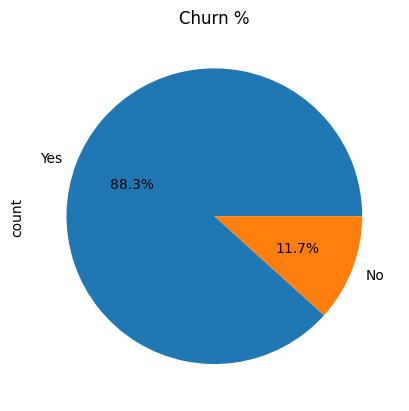

In [133]:
df['Churn'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Churn %')
plt.show()

In [114]:
# Convert target variable

In [134]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [ ]:
# Exploratory Data Analysis (EDA - Visualization) : Churn Distribution (Bar Plot)

This plot provides a bar chart visualization of the Churn distribution. It clearly shows a much larger count of '1' (churn) compared to '0' (no churn).

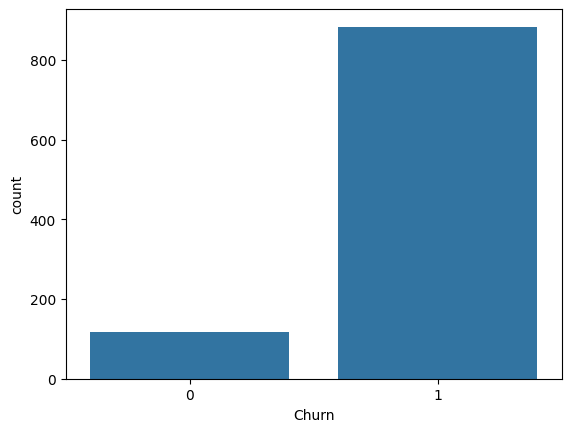

In [136]:
sns.countplot(x='Churn', data=df)
plt.show()

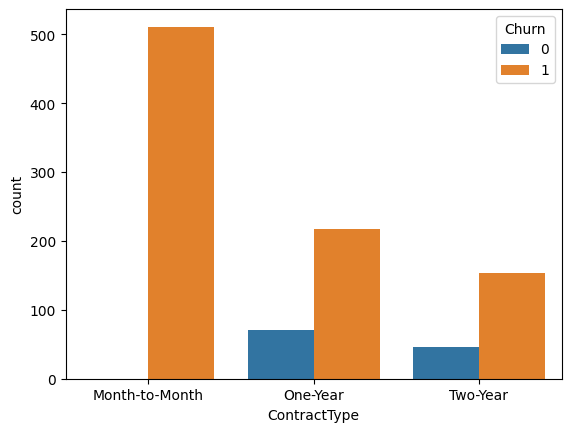

In [137]:
# Churn vs Contract Type : This bar plot helps us understand the relationship between ContractType and Churn. By observing the counts of churned vs. non-churned customers for each contract type (Month-to-Month, One-Year, Two-Year), we can infer that customers with Month-to-Month contracts appear to have a higher churn rate compared to those with longer-term contracts.


sns.countplot(x='ContractType', hue='Churn', data=df)
plt.show()

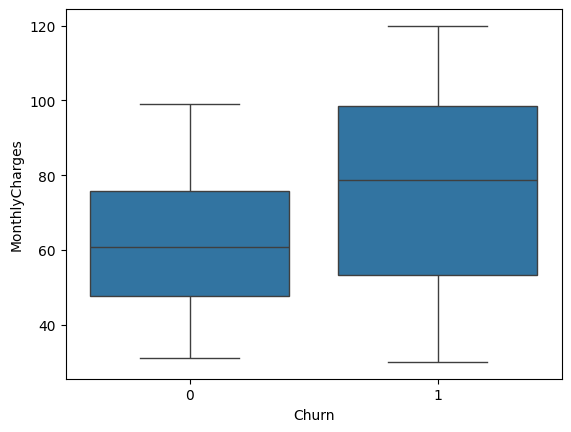

In [138]:
# Monthly Charges vs Churn : The box plot visualizes the distribution of MonthlyCharges for churned and non-churned customers. It often reveals that customers with higher monthly charges tend to have a higher propensity to churn.

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

In [ ]:
# Correlation Heatmap : This heatmap displays the correlation matrix for all numerical variables in the DataFrame.

From the correlation heatmap, I observed that tenure has a strong positive correlation with total charges (0.89) and a negative correlation with churn (-0.22), indicating that long-term customers are less likely to churn. Monthly charges show a slight positive correlation with churn, suggesting pricing may influence customer retention.

Customers with low tenure and higher monthly charges are more likely to churn, while long-term customers generate higher total revenue and are less likely to leave.


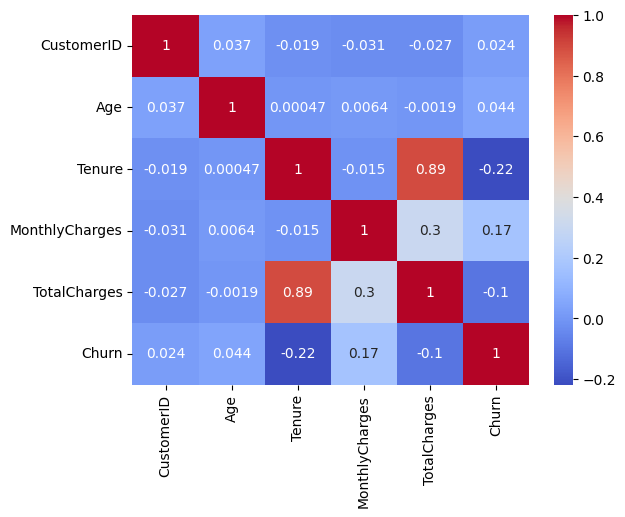

In [139]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# Data Preparation for Modeling : Convert categorical variables - We convert all remaining categorical variables (e.g., Gender, ContractType, InternetService, TechSupport) into numerical format.

In [141]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
# Split data : Before building a model, the data is split into features (X) and the target variable (y). X contains all columns except Churn, and y is the Churn column. Then, train_test_split divides the data into training (80%) and testing (20%) sets. This ensures that the model is trained on one part of the data and evaluated on unseen data to assess its generalization performance.

In [143]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
# Model Building - Logistic Regression : A Logistic Regression model is chosen for this binary classification task (churn or no churn). It's a simple yet effective model for predicting probabilities.

In [147]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [ ]:
# Model Evaluation : After training, the model's performance is evaluated on the unseen test data (X_test).

In [148]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.915
[[ 14  16]
 [  1 169]]
              precision    recall  f1-score   support

           0       0.93      0.47      0.62        30
           1       0.91      0.99      0.95       170

    accuracy                           0.92       200
   macro avg       0.92      0.73      0.79       200
weighted avg       0.92      0.92      0.90       200



In [ ]:
# Feature Importance: This step extracts the coefficients of the Logistic Regression model, which represent the importance (and direction) of each feature in predicting the target variable. A higher absolute coefficient value indicates greater importance.

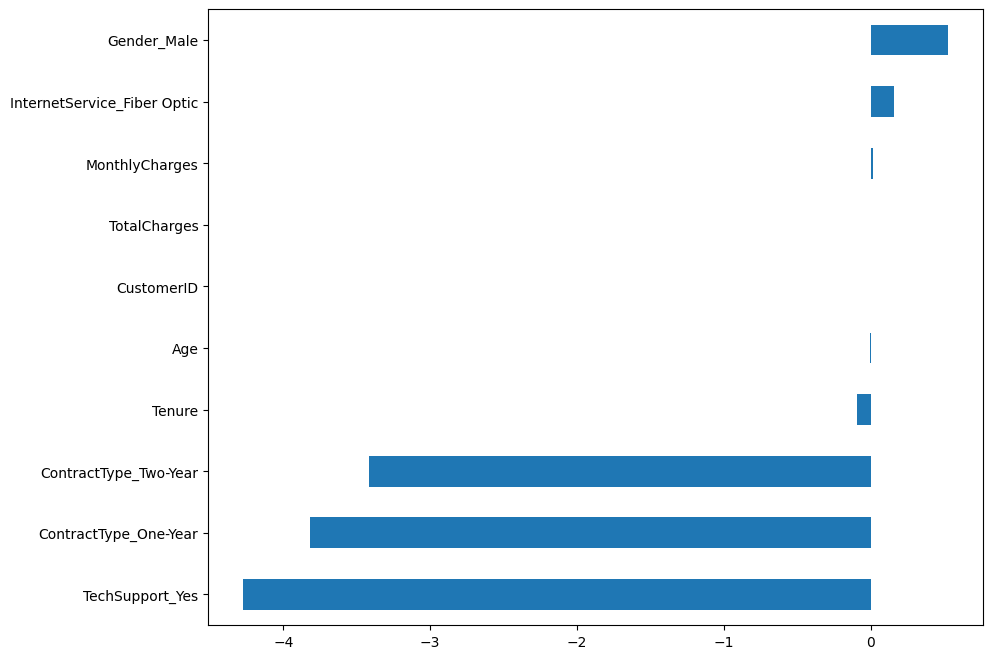

In [149]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(10,8))
plt.show()

**Business Insights & Recommendations**

Based on the analysis, here are the key insights and potential recommendations:

**Key Insights:**

1. Contract Type: Customers on month-to-month contracts have a significantly higher churn rate compared to those with one-year or two-year contracts. This is a crucial finding, as longer contract terms seem to foster loyalty.

2. Monthly Charges: Higher MonthlyCharges are associated with an increased likelihood of churn. This suggests that pricing strategies or value perception might be an issue for some customers.

3. Tenure: Customers with shorter tenure are more prone to churning. This indicates that the initial period of a customer's service is critical for retention.

4. Internet Service: Fiber Optic internet service appears to be associated with higher churn, while TechSupport seems to significantly reduce churn.

5. Gender: Male customers showed a slightly higher positive coefficient for churn compared to female customers (if Gender_Male is True).


**Recommendations:**

1. Promote Long-Term Contracts: Offer incentives (discounts, bundled services) to encourage customers to switch from month-to-month to one-year or two-year contracts.

2. Review Pricing Strategy: Analyze customers with high monthly charges who churn. Consider offering personalized plans or value-added services to justify the cost and prevent dissatisfaction.

3. Improve Onboarding & Early Engagement: Implement robust onboarding programs for new customers to ensure satisfaction and address any initial issues promptly. Proactive check-ins and exclusive offers for new customers during their first few months could be beneficial.

4. Enhance Tech Support: Since TechSupport is a strong negative predictor of churn, invest further in improving the quality and accessibility of technical support to enhance customer satisfaction.

5. Targeted Interventions: Use the model to identify customers at high risk of churning (especially those with month-to-month contracts, high monthly charges, or short tenure) and initiate proactive retention campaigns. This could include personalized offers, loyalty programs, or direct outreach.


This project successfully used data analysis and a Logistic Regression model to uncover significant drivers of customer churn in the telecom sector, providing actionable insights for retention strategies.